# Type 2 Diabetes Risk Prediction

In [25]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns


In [26]:
#import dataset
tabela = pd.read_csv("diabetes.csv")

display(tabela)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [27]:
#number of rows and columns
print(tabela.shape)

#column information
print(tabela.info())

(768, 9)
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [28]:
#dataset contains many impossible values (like 0) in some columns
#replace them for NaN
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
tabela[cols] = tabela[cols].replace(0, np.nan)

The dataset contains many impossible values (0) in some columns, such as "Insulin", "SkinThickness", "Glucose", "BloodPressure" and "BMI". Zeros in these columns are biologically impossible. They were replaced with NaN, this represent invalid, undefined or absent data. 

In [29]:
#replace NaN with median
tabela.fillna(tabela.median(), inplace=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1


The NaN values were imputed by the median of each column, as this is a measure robust to outliers.

In [30]:
#summary of count, mean, standard deviation, min and max for numeric variables.
tabela.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


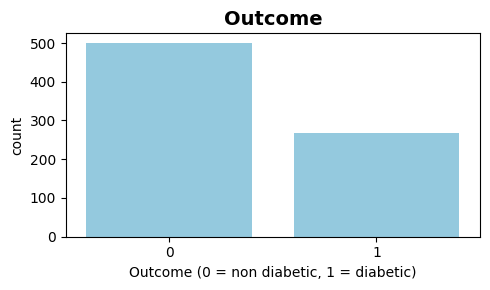

In [31]:
#countplot for "Outcome" feature
plt.figure(figsize=(5, 3))
plt.title("Outcome", fontsize=14, fontweight="bold")
sns.countplot(x=tabela["Outcome"], color="skyblue")
plt.xlabel("Outcome (0 = non diabetic, 1 = diabetic)")
plt.tight_layout()
plt.show()

The dataset is imbalanced, 500 non-diabetic and 268 diabetic cases. This means the model will see nearly twice as many negative examples during training.

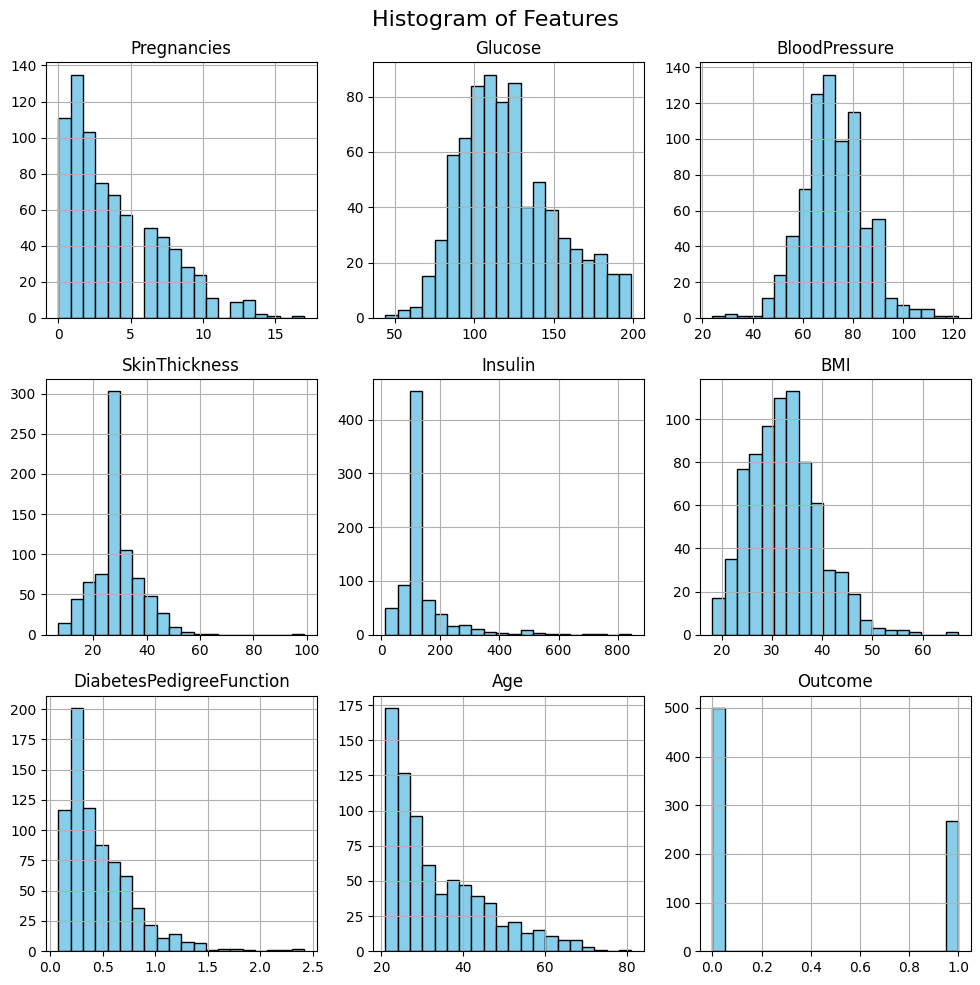

In [32]:
#histogram of features
tabela.hist(bins=20, figsize=(10, 10), color="skyblue", edgecolor="black")
plt.suptitle("Histogram of Features", fontsize=16)
plt.tight_layout()
plt.show()

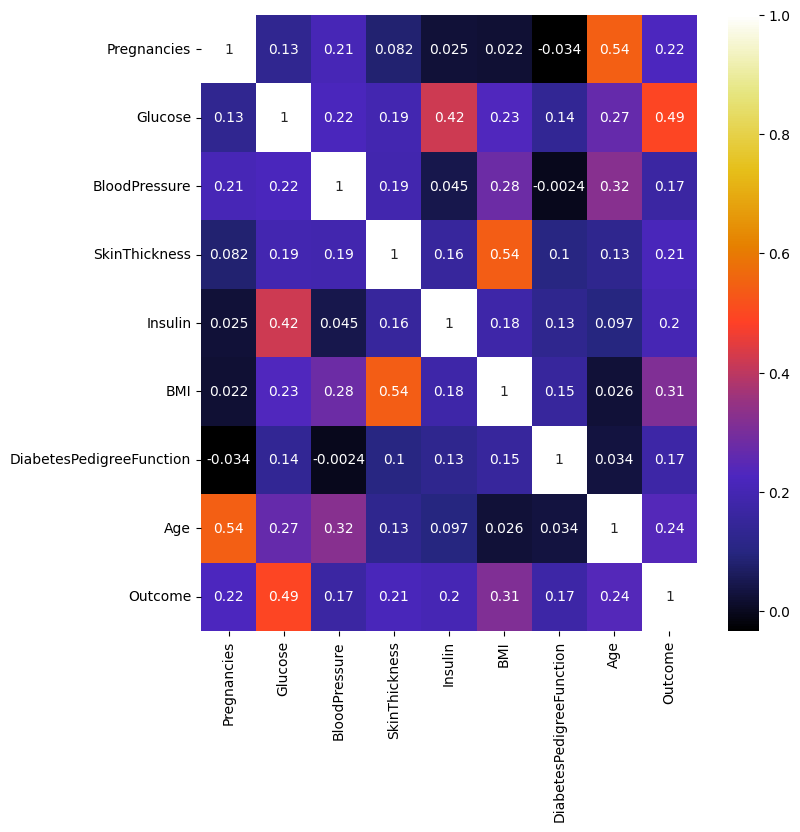

In [33]:
#heatmap of correlations 
plt.figure(figsize=(8,8))
sns.heatmap(tabela.corr(), cmap="CMRmap",annot=True)
plt.show()


The heatmap reveals that Glucose is the variable most correlated with the Outcome (r = 0.49). Followed by BMI and Age.

In [34]:
#Correlation between Glucose and Outcome
from scipy.stats import pearsonr
corr, p_value = pearsonr(
    tabela["Glucose"],
    tabela["Outcome"]
)

print("Correlation:", corr)
print("p-value:", p_value)
if p_value < 0.05:
    print("Statistically significant result")
else:
    print("Not significant")



Correlation: 0.492782403915027
p-value: 3.128719041842022e-48
Statistically significant result


A positive correlation (0.49) was observed between Glucose and Outcome. The result was statistically significant (p < 0.05), indicating evidence of association between the variables in the dataset


In [35]:
#Correlation between BMI and Outcome
from scipy.stats import pearsonr
corr, p_value = pearsonr(
    tabela["BMI"],
    tabela["Outcome"]
)

print("Correlation:", corr)
print("p-value:", p_value)
if p_value < 0.05:
    print("Statistically significant result")
else:
    print("Not significant")

Correlation: 0.3120383386771114
p-value: 8.336902677507209e-19
Statistically significant result


A positive correlation (0.31) was observed between BMI and Outcome. The result was statistically significant (p < 0.05), indicating evidence of association between the variables in the dataset

In [36]:
#Correlation between Age and Outcome
from scipy.stats import pearsonr
corr, p_value = pearsonr(
    tabela["Age"],
    tabela["Outcome"]
)

print("Correlation:", corr)
print("p-value:", p_value)
if p_value < 0.05:
    print("Statistically significant result")
else:
    print("Not significant")

Correlation: 0.2383559830271977
p-value: 2.2099754606653305e-11
Statistically significant result


A positive correlation (0.24) was observed between Age and Outcome. The result was statistically significant (p < 0.05), indicating evidence of association between the variables in the dataset

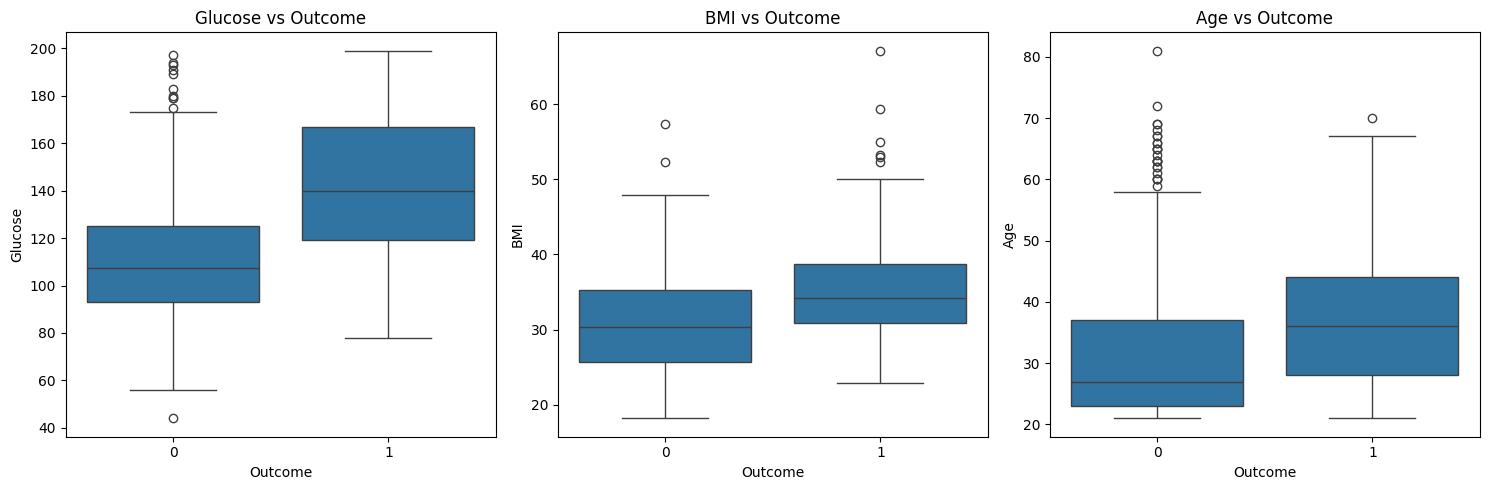

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Glucose
sns.boxplot(x='Outcome', y='Glucose', data=tabela, ax=axes[0])
axes[0].set_title('Glucose vs Outcome')

# BMI
sns.boxplot(x='Outcome', y='BMI', data=tabela, ax=axes[1])
axes[1].set_title('BMI vs Outcome')

# Age
sns.boxplot(x='Outcome', y='Age', data=tabela, ax=axes[2])
axes[2].set_title('Age vs Outcome')

plt.tight_layout()
plt.show()

This figure presents the distribution of key variables (Glucose, BMI, and Age) across the outcome classes. All three features show higher median values for diabetic patients, reinforcing their importance in predicting the condition.

## Model Training

In [38]:
from sklearn.model_selection import train_test_split
#y -> this is the column in the dataset that I want to predict.
y = tabela["Outcome"]

#x -> the columns of the dataset that I will use to make the prediction
x = tabela.drop(columns="Outcome")

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
#create AI
randomforest_model = RandomForestClassifier(n_estimators=100, random_state=42)
regression_model = LogisticRegression(max_iter=1000)

#training AI
randomforest_model.fit(x_train, y_train)
regression_model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [40]:
from sklearn.metrics import accuracy_score
#making predictions and comparing the accuracy of models.
predictions_regression = regression_model.predict(x_test)
predictions_randomforest = randomforest_model.predict(x_test)

display("Random Forest", accuracy_score(y_test, predictions_randomforest))
display("Logistic Regression", accuracy_score(y_test, predictions_regression))

'Random Forest'

0.7467532467532467

'Logistic Regression'

0.7532467532467533

Both models achieved similar accuracy (~75%), with Logistic Regression performing slightly better. This suggests that the relationships between the features and the outcome may be relatively linear, which allows a simpler model to perform just as well as a more complex one.

In [41]:
#import new patients for prediction
new_patients = pd.read_csv("pacientes.csv")

display(new_patients)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,2,120,70,25,80,28.5,0.45,32
1,5,150,85,30,130,35.2,0.67,45
2,1,95,65,20,70,24.1,0.30,28
3,3,180,90,35,200,40.0,0.90,50
4,0,110,68,22,85,26.7,0.40,26
5,4,140,80,28,120,33.5,0.75,38
6,6,160,88,32,170,37.8,0.85,55
7,2,105,72,24,90,27.0,0.50,34
8,7,190,95,40,220,42.3,1.10,60
9,1,100,66,21,75,25.5,0.35,29


In [42]:
#verify that the new patients do not have null values ​​and the target column "Outcome".
assert new_patients.isnull().sum().sum() == 0
assert "Outcome" not in new_patients.columns

In [43]:
#ensure the same columns used in training
X_new = new_patients[x.columns]

#predict diagnosis and probability for new patients
new_predictions_regression = regression_model.predict(X_new)
new_probability_regression = regression_model.predict_proba(X_new)[:,1]

new_predictions_randomforest = randomforest_model.predict(X_new)
new_probability_randomforest = randomforest_model.predict_proba(X_new)[:,1]

#add predictions and probabilities to the dataframe
new_patients["Pred_regression"] = new_predictions_regression
new_patients["Prob_regression"] = new_probability_regression

new_patients["Pred_rforest"] = new_predictions_randomforest
new_patients["Prob_rforest"] = new_probability_randomforest

display(new_patients)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Pred_regression,Prob_regression,Pred_rforest,Prob_rforest
0,2,120,70,25,80,28.5,0.45,32,0,0.197977,0,0.27
1,5,150,85,30,130,35.2,0.67,45,1,0.717965,1,0.65
2,1,95,65,20,70,24.1,0.30,28,0,0.046303,0,0.02
3,3,180,90,35,200,40.0,0.90,50,1,0.928505,1,0.87
4,0,110,68,22,85,26.7,0.40,26,0,0.088576,0,0.08
5,4,140,80,28,120,33.5,0.75,38,1,0.547292,1,0.61
6,6,160,88,32,170,37.8,0.85,55,1,0.880244,1,0.88
7,2,105,72,24,90,27.0,0.50,34,0,0.112472,0,0.25
8,7,190,95,40,220,42.3,1.10,60,1,0.978910,1,0.81
9,1,100,66,21,75,25.5,0.35,29,0,0.066142,0,0.05


Among the 10 new patients, 4 were classified as non-diabetic and 6 as diabetic by both models. Patient 8 presented the highest diabetes probability (97% — Logistic Regression, 81% — Random Forest), which is consistent with their clinical profile: the highest Glucose (190), BMI (42.3), Insulin (220) and Age (60) in the group. 

Patient 3 also showed high risk (93% and 87%), driven by elevated Glucose (180), BMI (40) and a high DiabetesPedigreeFunction (0.90), which reflects strong family history. 

On the other end, Patient 2 was classified as non-diabetic with very low probability (4.6% and 2%), presenting the lowest Glucose (95) and BMI (24.1) in the group. 

Both models agreed on the classification of all 10 patients, which reinforces the consistency of the predictions.

Although both models agreed on all classifications, the Logistic Regression showed higher and more consistent probabilities, which is aligned with its slightly better accuracy on the test set.

In [44]:
#detailed performance report (precision, recall, f1-score)
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
print("Logistic Regression", classification_report(y_test, predictions_regression))
print("Random Forest", classification_report(y_test, predictions_randomforest))

Logistic Regression               precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154

Random Forest               precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



The classification report provides a more detailed view of each model's performance beyond overall accuracy.

Logistic Regression performed better at identifying non-diabetic patients (recall of 0.83 for class 0), while Random Forest showed a slightly better ability to detect diabetic patients (recall of 0.67 for class 1, compared to 0.62 for Logistic Regression).

This distinction is particularly important in a medical context, where failing to identify a diabetic patient (false negative) is generally more critical than incorrectly classifying a healthy patient as diabetic (false positive).

Both models showed weaker performance in predicting the diabetic class (class 1), which is expected given the class imbalance in the dataset, as the models were trained on a significantly higher number of non-diabetic examples.

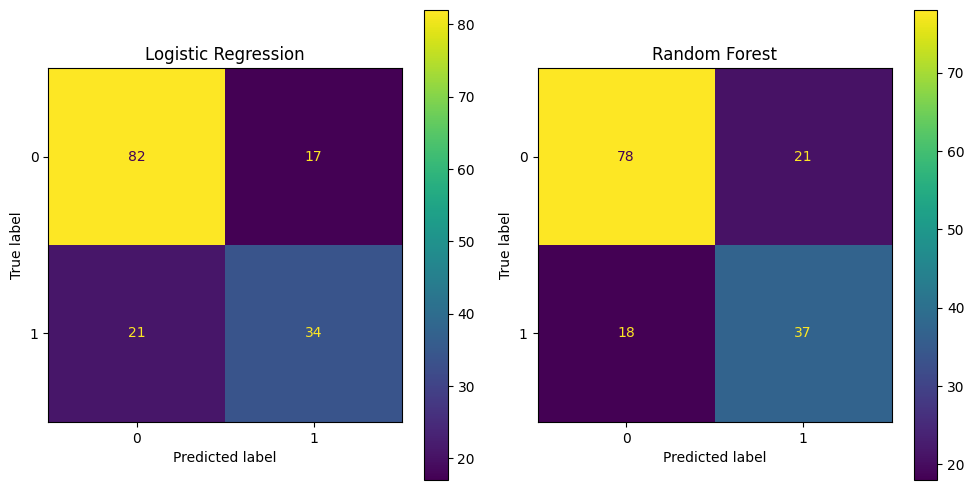

In [45]:
#create confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

ConfusionMatrixDisplay.from_predictions(y_test, predictions_regression, ax=axes[0])
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(y_test, predictions_randomforest, ax=axes[1])
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()

The confusion matrix reinforces these findings with concrete numbers. The Logistic Regression correctly identified 82 non-diabetic patients and 34 diabetic patients, but produced 21 false negatives, diabetic patients incorrectly classified as healthy. The Random Forest, despite similar overall accuracy, reduced false negatives to 18, making it a safer choice in a clinical context where missing a diabetic diagnosis carries greater risk than a false alarm.

# Conclusion
Both models achieved similar accuracy (~75%), with Logistic Regression performing slightly better. Among the 10 new patients, 6 were classified as diabetic and 4 as non-diabetic, with both models agreeing on all predictions, reinforcing their consistency.

Glucose, BMI, and Age were the features that most influenced high-risk classifications, which is consistent with clinical findings related to Type 2 Diabetes.

As for limitations, the dataset is relatively small (768 samples), and missing values were imputed using the median, a simple approach that may not fully capture the true variability of patient data. Additionally, the dataset is imbalanced, which can impact model performance, especially in identifying diabetic cases.

Future work could explore larger datasets, more robust imputation methods, and techniques to address class imbalance in order to improve model generalization.